In [1]:
from imutils import paths
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle
import random
import timeit

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input, BatchNormalization
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import losses
from tensorflow.keras import datasets, layers, models
import tensorflow as tf

import tensorflow_addons as tfa

from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.applications.xception import decode_predictions

2022-10-30 18:38:53.673618: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:
from pyFile import ARModel
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
import numpy as np

import matplotlib.pyplot as plt

In [3]:
modelAvl = ["vgg16","vgg19","inception","xception","resnet50","resnet101","densenet","inceptionResnet"]
modelSel = ["inception", "xception" ]
modelOnly = ["xception"]
losses = ["bce", "cce", "focal", "kld"]
lossSel = ["bce", "focal"]
lossOnly = ["focal"]

In [4]:
def fix_gpu():
    config = ConfigProto()
    config.gpu_options.allow_growth = True
    session = InteractiveSession(config=config)

fix_gpu()

2022-10-30 18:38:54.404065: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-10-30 18:38:54.406283: I tensorflow/compiler/jit/xla_gpu_device.cc:99] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-10-30 18:38:54.406881: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2022-10-30 18:38:54.457166: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-30 18:38:54.457334: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 na

In [5]:
model = ARModel()

In [6]:
(data, labels) = model.loadImages(r'/home/bishal/Research/Allergic-Rhinitis/Dataset/all/rotate', 
        plotType="R", classification="multiclass", colorMode="RGB", cleanImageF=True, resize=True,
        correctColor=False, contours=False, crop=True ,printImgDemo=False)

[INFO]: Trying to Read the images from  /home/bishal/Research/Allergic-Rhinitis/Dataset/all/rotate
Images found : 90


In [7]:
(data, labels) = model.prepareData(data, labels, weightedLossCalc=True)

[INFO]: Preparing Data
{'imgNumber': 111, 'dataInfo': 'R', 'classification': 'multiclass', 'imageCount': 90, 'imageType': 'R', 'classType': 'multiclass', 'colorMode': 'RGB', 'clean': True, 'crop': True, 'resize': True, 'colorCorrect': False, 'imgDim': (224, 224, 3)}


In [8]:
trainAug = model.setDataAugmentation(normalizeData=False, rotate=2, zoom=0.15, wShift=0.2, hShift=0.2, 
                                shear=0.15, hFlip=True, vFlip=False, generateImages=False)


[INFO]: Augmenting Data with - 
{'rotate': 2, 'zoom': 0.15, 'wShift': 0.2, 'hShift': 0.2, 'shear': 0.15, 'hFlip': True, 'vFlip': False}


In [9]:
#plt.imshow(trainX[54])

In [10]:
#(trainX, trainY, testX, testY) = model.setPartition(data, labels, testSize=0.20)

In [11]:
#testY = np.expand_dims(testY, 0)
#testX = np.expand_dims(testX, 0)

In [12]:
#testY

In [13]:
#testX.shape

In [14]:
len(data)

90

In [15]:
currBModel = model.setBaseModel("xception")
                
currHModel = model.setHeadModel(currBModel, dropoutRate=0.5, activation="siren")
finalModel = model.initModel(currBModel, currHModel, baseTrainable=False)
model.setHyperParameters(learningRate = 1e-3, epochs = 200, batchSize = 8)
finalModel = model.compileModel(finalModel, loss="focal")

2022-10-30 18:38:56.028871: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-10-30 18:38:56.029108: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-30 18:38:56.029279: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA TITAN RTX computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 23.65GiB deviceMemoryBandwidth: 625.94GiB/s
2022-10-30 18:38:56.029331: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2022-10-30 18:38:56.029349: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2022-10-30 18:38:56.029361: I tensorflow/stream_executor/platform/defaul

[INFO]: Model Selected -  xception
[INFO]: Initializing Model
[INFO]: Hyperparameters Set
[INFO]: Compiling Model


In [16]:
y_hat = []
y = []
start = timeit.default_timer()
for i in range(len(data)):
    print("#### Iter - %s ####"%str(i+1))
    trainX = np.delete(data, [i], axis=0)
    trainY = np.delete(labels, [i], axis=0)
    testX = np.expand_dims(data[i], 0)
    testY = np.expand_dims(labels[i], 0)
    y.append(labels[i])
    print("Sizes : ", trainX.shape, "--", trainY.shape)
    print("Sizes : ", testX.shape, "--", testY.shape)
    
    (H, finalModel) = model.startTraining(finalModel, trainAug, trainX, trainY, 
                                            testX, testY, weightedLoss=True, learningDecay=False, earlyStop=True)
    
    predIdxs = model.startTesting(testX, testY, finalModel, voting=30)
    y_hat.append(predIdxs[0])
stop = timeit.default_timer()

#### Iter - 1 ####
Sizes :  (89, 224, 224, 3) -- (89, 3)
Sizes :  (1, 224, 224, 3) -- (1, 3)
[INFO] Model Training
Epoch 1/200


2022-10-30 18:38:56.730402: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2022-10-30 18:38:56.747023: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 3693095000 Hz
2022-10-30 18:38:58.082427: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2022-10-30 18:38:58.207206: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7


11/11 [==============================] - 3s 66ms/step - loss: 0.7420 - accuracy: 0.1708

Epoch 00001: loss improved from inf to 0.80919, saving model to AR_MODEL.hdf5
Epoch 2/200
11/11 [==============================] - 0s 41ms/step - loss: 0.5814 - accuracy: 0.3655

Epoch 00002: loss improved from 0.80919 to 0.49077, saving model to AR_MODEL.hdf5
Epoch 3/200
11/11 [==============================] - 0s 40ms/step - loss: 0.5027 - accuracy: 0.3285

Epoch 00003: loss improved from 0.49077 to 0.46966, saving model to AR_MODEL.hdf5
Epoch 4/200
11/11 [==============================] - 0s 42ms/step - loss: 0.4235 - accuracy: 0.4237

Epoch 00004: loss did not improve from 0.46966
Epoch 5/200
11/11 [==============================] - 0s 41ms/step - loss: 0.4530 - accuracy: 0.3815

Epoch 00005: loss improved from 0.46966 to 0.46065, saving model to AR_MODEL.hdf5
Epoch 6/200
11/11 [==============================] - 0s 41ms/step - loss: 0.3229 - accuracy: 0.4886

Epoch 00006: loss improved from 0.4

Epoch 29/200
11/11 [==============================] - 0s 45ms/step - loss: 0.1188 - accuracy: 0.7910

Epoch 00029: loss did not improve from 0.14664
Epoch 30/200
11/11 [==============================] - 0s 42ms/step - loss: 0.1130 - accuracy: 0.6853

Epoch 00030: loss did not improve from 0.14664
Epoch 31/200
11/11 [==============================] - 0s 39ms/step - loss: 0.2107 - accuracy: 0.6592

Epoch 00031: loss did not improve from 0.14664
Epoch 32/200
11/11 [==============================] - 0s 39ms/step - loss: 0.1377 - accuracy: 0.7313

Epoch 00032: loss did not improve from 0.14664
Epoch 33/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1738 - accuracy: 0.6415

Epoch 00033: loss did not improve from 0.14664
Epoch 34/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1822 - accuracy: 0.5900

Epoch 00034: loss did not improve from 0.14664
Epoch 35/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1493 - accuracy: 0.7411

Epoc

Epoch 58/200
11/11 [==============================] - 0s 39ms/step - loss: 0.0727 - accuracy: 0.8553

Epoch 00058: loss did not improve from 0.08250
Epoch 59/200
11/11 [==============================] - 1s 43ms/step - loss: 0.0869 - accuracy: 0.7457

Epoch 00059: loss did not improve from 0.08250
Epoch 60/200
11/11 [==============================] - 0s 40ms/step - loss: 0.1018 - accuracy: 0.8279

Epoch 00060: loss did not improve from 0.08250
Epoch 61/200
11/11 [==============================] - 0s 40ms/step - loss: 0.1216 - accuracy: 0.7559

Epoch 00061: loss did not improve from 0.08250
Epoch 62/200
11/11 [==============================] - 0s 41ms/step - loss: 0.1093 - accuracy: 0.7702

Epoch 00062: loss did not improve from 0.08250
Epoch 63/200
11/11 [==============================] - 0s 39ms/step - loss: 0.0921 - accuracy: 0.7554

Epoch 00063: loss did not improve from 0.08250
Epoch 64/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0742 - accuracy: 0.8435

Epoc

...

11/11 [==============================] - 0s 43ms/step - loss: 0.0791 - accuracy: 0.7531

Epoch 00063: loss did not improve from 0.04414
Epoch 64/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0570 - accuracy: 0.7901

Epoch 00064: loss did not improve from 0.04414
Epoch 65/200
11/11 [==============================] - 1s 45ms/step - loss: 0.0740 - accuracy: 0.8182

Epoch 00065: loss did not improve from 0.04414
Epoch 66/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0496 - accuracy: 0.8148

Epoch 00066: loss did not improve from 0.04414
Epoch 67/200
11/11 [==============================] - 1s 43ms/step - loss: 0.0564 - accuracy: 0.8409

Epoch 00067: loss did not improve from 0.04414
Epoch 68/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0884 - accuracy: 0.7901

Epoch 00068: loss did not improve from 0.04414
Epoch 69/200
11/11 [==============================] - 0s 37ms/step - loss: 0.0789 - accuracy: 0.7778

Epoch 00069: loss

11/11 [==============================] - 0s 38ms/step - loss: 0.0463 - accuracy: 0.8395

Epoch 00092: loss did not improve from 0.04414
Epoch 93/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0549 - accuracy: 0.8395

Epoch 00093: loss did not improve from 0.04414
Epoch 94/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0930 - accuracy: 0.7531

Epoch 00094: loss did not improve from 0.04414
Epoch 95/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0668 - accuracy: 0.8395

Epoch 00095: loss did not improve from 0.04414
Epoch 96/200
11/11 [==============================] - 1s 45ms/step - loss: 0.0790 - accuracy: 0.7386

Epoch 00096: loss did not improve from 0.04414
Epoch 97/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0791 - accuracy: 0.7531

Epoch 00097: loss did not improve from 0.04414
Epoch 98/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0825 - accuracy: 0.7407

Epoch 00098: loss

11/11 [==============================] - 0s 40ms/step - loss: 0.0649 - accuracy: 0.7654

Epoch 00121: loss did not improve from 0.04414
Epoch 122/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0773 - accuracy: 0.7160

Epoch 00122: loss did not improve from 0.04414
Epoch 123/200
11/11 [==============================] - 0s 46ms/step - loss: 0.0409 - accuracy: 0.8889

Epoch 00123: loss improved from 0.04414 to 0.04091, saving model to AR_MODEL.hdf5
Epoch 124/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0549 - accuracy: 0.8395

Epoch 00124: loss did not improve from 0.04091
Epoch 125/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0647 - accuracy: 0.8395

Epoch 00125: loss did not improve from 0.04091
Epoch 126/200
11/11 [==============================] - 0s 39ms/step - loss: 0.0949 - accuracy: 0.7531

Epoch 00126: loss did not improve from 0.04091
Epoch 127/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0

Epoch 150/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0754 - accuracy: 0.8025

Epoch 00150: loss did not improve from 0.04091
Epoch 151/200
11/11 [==============================] - 0s 46ms/step - loss: 0.0565 - accuracy: 0.8519

Epoch 00151: loss did not improve from 0.04091
Epoch 152/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0673 - accuracy: 0.7531

Epoch 00152: loss did not improve from 0.04091
Epoch 153/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0973 - accuracy: 0.6790

Epoch 00153: loss did not improve from 0.04091
Epoch 154/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0662 - accuracy: 0.8272

Epoch 00154: loss did not improve from 0.04091
Epoch 155/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0805 - accuracy: 0.8025

Epoch 00155: loss did not improve from 0.04091
Epoch 156/200
11/11 [==============================] - 0s 43ms/step - loss: 0.0714 - accuracy: 0.777

11/11 [==============================] - 0s 45ms/step - loss: 0.0671 - accuracy: 0.8025

Epoch 00179: loss did not improve from 0.04091
Epoch 180/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0607 - accuracy: 0.8272

Epoch 00180: loss did not improve from 0.04091
Epoch 181/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0640 - accuracy: 0.8272

Epoch 00181: loss did not improve from 0.04091
Epoch 182/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0573 - accuracy: 0.8642

Epoch 00182: loss did not improve from 0.04091
Epoch 183/200
11/11 [==============================] - 0s 40ms/step - loss: 0.0666 - accuracy: 0.7654

Epoch 00183: loss did not improve from 0.04091
Epoch 184/200
11/11 [==============================] - 0s 41ms/step - loss: 0.0607 - accuracy: 0.8519

Epoch 00184: loss did not improve from 0.04091
Epoch 185/200
11/11 [==============================] - 0s 42ms/step - loss: 0.0627 - accuracy: 0.7901

Epoch 00185

In [17]:
print("Total Time - ",stop-start)

Total Time -  9163.88418024988


In [18]:
print((stop-start) / 3600)

2.5455233834027444


In [19]:
len(y)

90

In [20]:
y_org = []
for val in y:
    if val[0]:
        y_org.append(0)
    elif val[1]:
        y_org.append(1)
    elif val[2]:
        y_org.append(2)

In [21]:

len(y_org)

90

In [27]:
count = 0
for i in range(len(y_org)):
     if y_org[i] == y_hat[i]:
            count += 1
acc = ((count / len(y_org) ) * 100)
acc

98.88888888888889

Final Plot Generated.


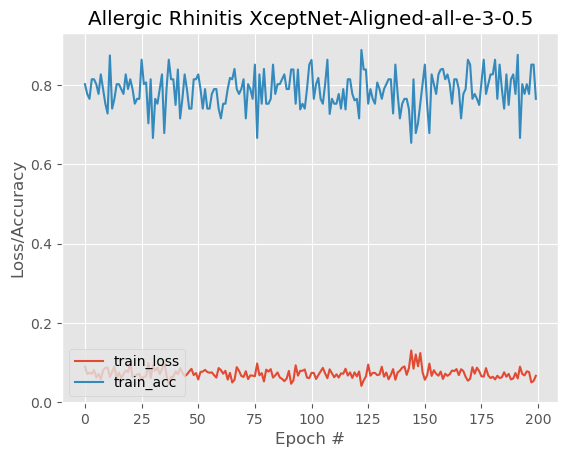

In [25]:
# plot the training loss and accuracy
# 플롯 그래프
print("Final Plot Generated.")
N = 200
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.title("Allergic Rhinitis XceptNet-Aligned-all-e-3-0.5")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")EPOCHS 
plt.legend(loc="lower left")
#plt.savefig("[iter-3] [XCEPTN] plot,rotate-1e3")